Assignment 2

In [24]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# Check missing values
df.isnull().sum()

# Fill missing Age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

# Fill Embarked
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_6887/3834269697.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_6887/3834269697.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [20]:
# Convert categorical to numeric
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

# Create new column
df['FamilySize'] = df['SibSp'] + df['Parch']

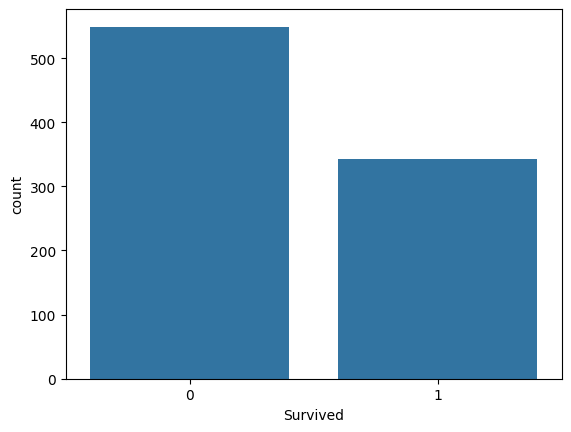

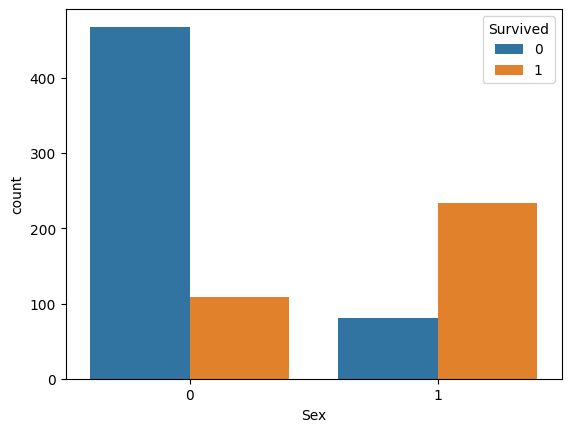

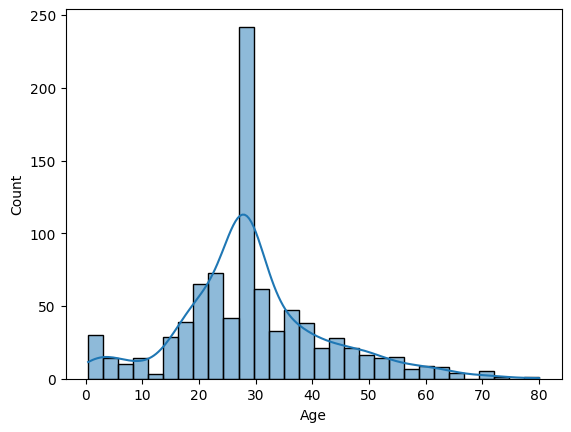

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Survival count
sns.countplot(x='Survived', data=df)
plt.show()

# Gender vs Survival
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

# Age distribution
sns.histplot(df['Age'], kde=True)
plt.show()

In [22]:
# Age groups
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[0,12,18,35,60,100],
                       labels=['Child','Teen','Adult','MidAge','Senior'])

# Fare category
df['FareCategory'] = pd.qcut(df['Fare'], 4,
                            labels=['Low','Medium','High','Very High'])

In [23]:
df.to_csv('cleaned_titanic.csv', index=False)